In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the CSV data
df = pd.read_csv('/Users/bernard/CascadeProjects/fs04/fs04_web/analytics/logs_raw_dump.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (863181, 61)

Column Names:
['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11', 'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21', 'c22', 'c23', 'c24', 'c25', 'c26', 'c27', 'c28', 'c29', 'c30', 'c31', 'c32', 'c33', 'c34', 'c35', 'c36', 'c37', 'c38', 'c39', 'c40', 'c41', 'c42', 'c43', 'c44', 'c45', 'c46', 'c47', 'c48', 'c49', 'c50', 'c51', 'c52', 'c53', 'c54', 'c55', 'c56', 'c57', 'c58', 'c59', 'c60', 'c61']

First 5 rows:
                    c1   c2   c3   c4   c5  c6  c7   c8   c9  c10  ... c52  \
0  1970-01-01 00:00:00  NaN  NaN  NaN  NaN   0   0  NaN  NaN  NaN  ... NaN   
1  1970-01-01 00:00:00  NaN  NaN  NaN  NaN   0   0  NaN  NaN  NaN  ... NaN   
2  1970-01-01 00:00:00  NaN  NaN  NaN  NaN   0   0  NaN  NaN  NaN  ... NaN   
3  1970-01-01 00:00:00  NaN  NaN  NaN  NaN   0   0  NaN  NaN  NaN  ... NaN   
4  1970-01-01 00:00:00  NaN  NaN  NaN  NaN   0   0  NaN  NaN  NaN  ... NaN   

  c53 c54 c55 c56 c57 c58 c59 c60 c61  
0 NaN NaN NaN 

In [2]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Unique values in categorical columns
if 'level' in df.columns:
    print("\nUnique log levels:")
    print(df['level'].value_counts())

if 'message' in df.columns:
    print("\nNumber of unique messages:", df['message'].nunique())

# Convert timestamp columns if they exist
date_columns = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
print(f"\nPotential date columns found: {date_columns}")

for col in date_columns:
    if col in df.columns:
        try:
            df[col] = pd.to_datetime(df[col])
            print(f"Converted {col} to datetime")
        except Exception as e:
            print(f"Could not convert {col} to datetime: {e}")

Missing Values:
c1          0
c2       5090
c3       5090
c4       5081
c5       5081
        ...  
c57    863181
c58    863181
c59    863181
c60    863181
c61         0
Length: 61, dtype: int64

Number of duplicate rows: 629461

Potential date columns found: []


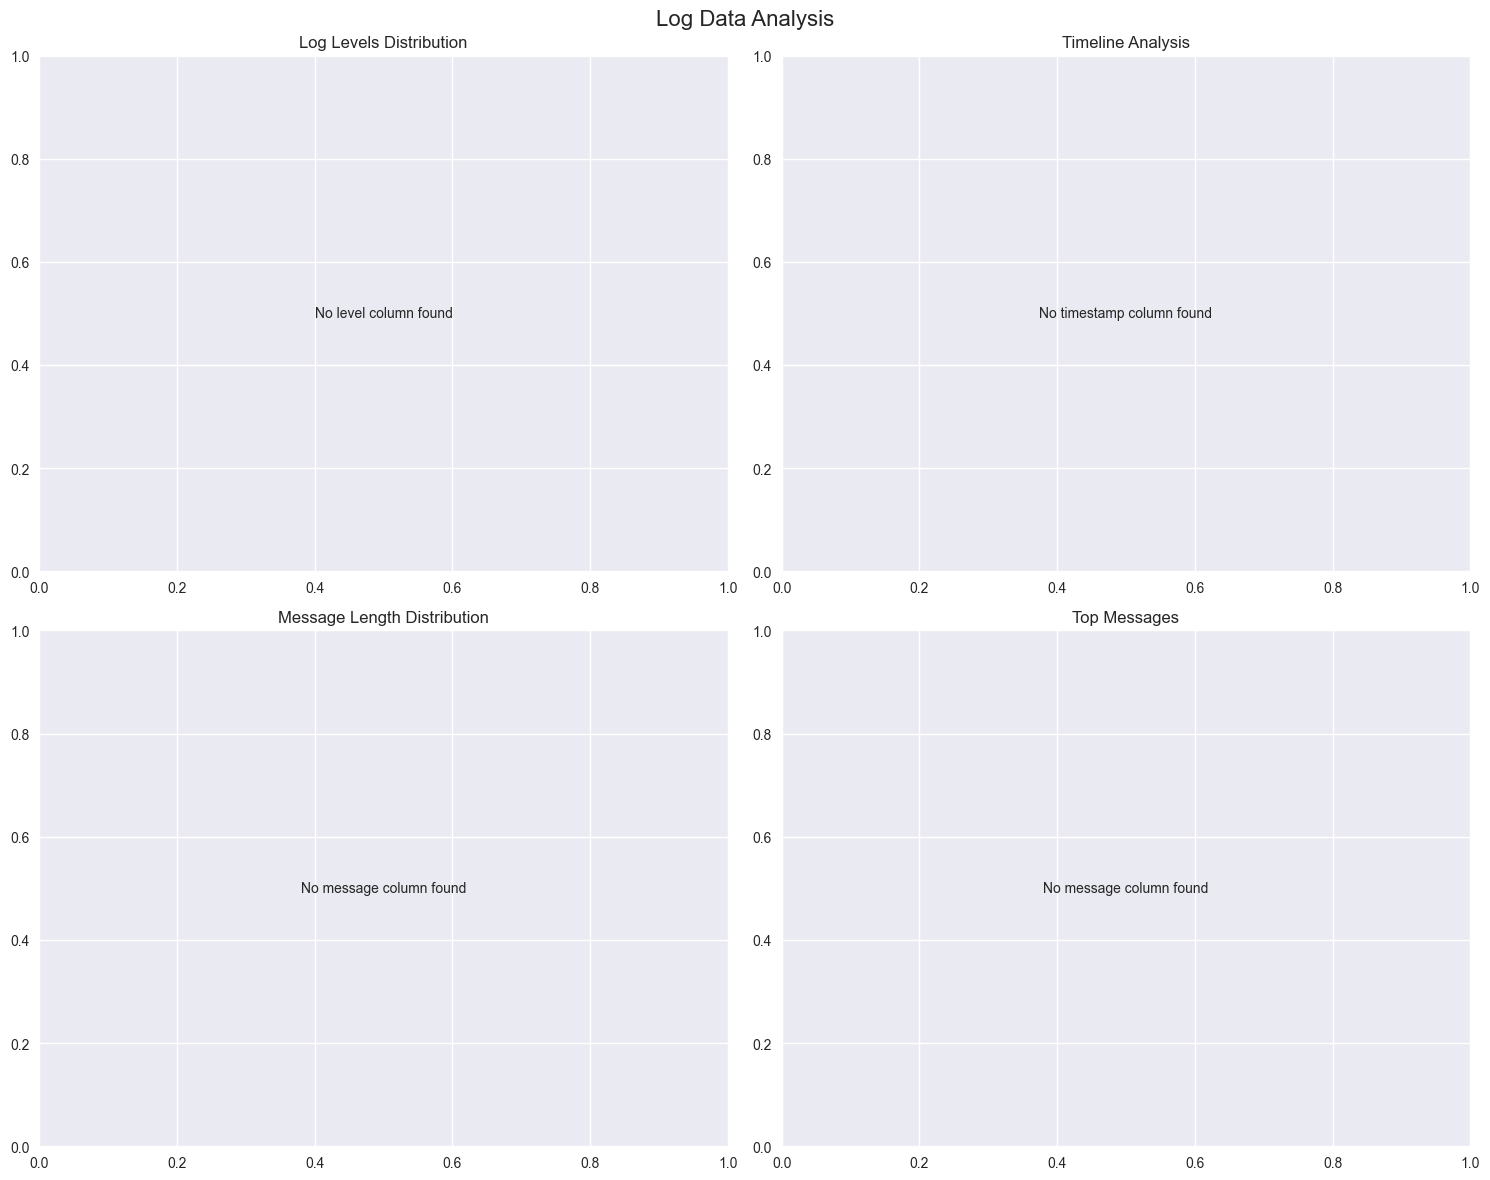

In [3]:
# Data visualization
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Log Data Analysis', fontsize=16)

# Plot 1: Log levels distribution
if 'level' in df.columns:
    level_counts = df['level'].value_counts()
    axes[0, 0].pie(level_counts.values, labels=level_counts.index, autopct='%1.1f%%')
    axes[0, 0].set_title('Log Levels Distribution')
else:
    axes[0, 0].text(0.5, 0.5, 'No level column found', ha='center', va='center')
    axes[0, 0].set_title('Log Levels Distribution')

# Plot 2: Timeline analysis if timestamp exists
time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
if time_cols:
    time_col = time_cols[0]
    if pd.api.types.is_datetime64_any_dtype(df[time_col]):
        df.groupby(df[time_col].dt.hour).size().plot(kind='bar', ax=axes[0, 1])
        axes[0, 1].set_title('Logs by Hour of Day')
        axes[0, 1].set_xlabel('Hour')
        axes[0, 1].set_ylabel('Count')
else:
    axes[0, 1].text(0.5, 0.5, 'No timestamp column found', ha='center', va='center')
    axes[0, 1].set_title('Timeline Analysis')

# Plot 3: Message length distribution
if 'message' in df.columns:
    message_lengths = df['message'].str.len()
    axes[1, 0].hist(message_lengths, bins=50, alpha=0.7)
    axes[1, 0].set_title('Message Length Distribution')
    axes[1, 0].set_xlabel('Message Length')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].text(0.5, 0.5, 'No message column found', ha='center', va='center')
    axes[1, 0].set_title('Message Length Distribution')

# Plot 4: Top 10 most frequent messages
if 'message' in df.columns:
    top_messages = df['message'].value_counts().head(10)
    axes[1, 1].barh(range(len(top_messages)), top_messages.values)
    axes[1, 1].set_yticks(range(len(top_messages)))
    axes[1, 1].set_yticklabels([msg[:30] + '...' if len(msg) > 30 else msg for msg in top_messages.index])
    axes[1, 1].set_title('Top 10 Most Frequent Messages')
    axes[1, 1].set_xlabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'No message column found', ha='center', va='center')
    axes[1, 1].set_title('Top Messages')

plt.tight_layout()
plt.show()

In [4]:
# Advanced analysis and insights
print("=" * 50)
print("ADVANCED LOG ANALYSIS")
print("=" * 50)

# Error analysis
if 'level' in df.columns and 'message' in df.columns:
    error_logs = df[df['level'].str.upper().isin(['ERROR', 'CRITICAL', 'FATAL'])]
    if not error_logs.empty:
        print(f"\nFound {len(error_logs)} error/critical logs")
        print("\nTop 5 error messages:")
        print(error_logs['message'].value_counts().head())
    else:
        print("\nNo error/critical logs found")

# Pattern analysis in messages
if 'message' in df.columns:
    print(f"\nMessage Analysis:")
    print(f"Average message length: {df['message'].str.len().mean():.2f} characters")
    print(f"Shortest message: {df['message'].str.len().min()} characters")
    print(f"Longest message: {df['message'].str.len().max()} characters")
    
    # Common patterns
    common_patterns = ['http', 'error', 'failed', 'success', 'warning', 'exception']
    pattern_counts = {}
    for pattern in common_patterns:
        count = df['message'].str.contains(pattern, case=False, na=False).sum()
        if count > 0:
            pattern_counts[pattern] = count
    
    if pattern_counts:
        print(f"\nCommon patterns in messages:")
        for pattern, count in sorted(pattern_counts.items(), key=lambda x: x[1], reverse=True):
            print(f"  {pattern}: {count} occurrences")

# Time-based patterns
time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
if time_cols and len(df) > 0:
    time_col = time_cols[0]
    if pd.api.types.is_datetime64_any_dtype(df[time_col]):
        print(f"\nTime-based Analysis:")
        print(f"Date range: {df[time_col].min()} to {df[time_col].max()}")
        print(f"Total time span: {(df[time_col].max() - df[time_col].min())}")
        
        # Busiest hours
        hourly_counts = df.groupby(df[time_col].dt.hour).size()
        busiest_hour = hourly_counts.idxmax()
        quietest_hour = hourly_counts.idxmin()
        print(f"Busiest hour: {busiest_hour}:00 ({hourly_counts[busiest_hour]} logs)")
        print(f"Quietest hour: {quietest_hour}:00 ({hourly_counts[quietest_hour]} logs)")

print(f"\nSummary Statistics:")
print(f"Total logs: {len(df)}")
print(f"Unique messages: {df['message'].nunique() if 'message' in df.columns else 'N/A'}")
print(f"Columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

ADVANCED LOG ANALYSIS

Summary Statistics:
Total logs: 863181
Unique messages: N/A
Columns: 61
Memory usage: 1489885.79 KB


In [ ]:
# Parse c1 as date and filter for December data
print("Original dataset shape:", df.shape)

# Check if c1 column exists
if 'c1' in df.columns:
    print("Found c1 column")
    print("Sample c1 values:")
    print(df['c1'].head(10))
    
    # Parse c1 as datetime
    try:
        df['parsed_date'] = pd.to_datetime(df['c1'])
        print("Successfully parsed c1 as datetime")
        
        # Filter for December (month 12)
        df_december = df[df['parsed_date'].dt.month == 12]
        print(f"December data shape: {df_december.shape}")
        
        # Show date range in December data
        if not df_december.empty:
            print(f"December date range: {df_december['parsed_date'].min()} to {df_december['parsed_date'].max()}")
            print(f"December days covered: {df_december['parsed_date'].dt.day.nunique()} unique days")
            
            # Update working dataframe to December data
            df = df_december.copy()
            print("Working dataframe updated to December data only")
        else:
            print("No December data found")
            
    except Exception as e:
        print(f"Error parsing c1 as datetime: {e}")
        # Try different date formats
        date_formats = [
            '%Y-%m-%d %H:%M:%S',
            '%Y-%m-%d',
            '%d/%m/%Y %H:%M:%S',
            '%d/%m/%Y',
            '%m/%d/%Y %H:%M:%S',
            '%m/%d/%Y'
        ]
        
        for fmt in date_formats:
            try:
                df['parsed_date'] = pd.to_datetime(df['c1'], format=fmt)
                print(f"Successfully parsed c1 using format: {fmt}")
                break
            except:
                continue
        else:
            print("Could not parse c1 with any common date format")
else:
    print("c1 column not found. Available columns:")
    print(df.columns.tolist())

In [6]:
# Filter for all December 2025 logs
print("Filtering for December 2025 logs")
print("=" * 50)

# First, let's load the full dataset again to ensure we have all data
df_full = pd.read_csv('/Users/bernard/CascadeProjects/fs04/fs04_web/analytics/logs_raw_dump.csv')
print(f"Full dataset shape: {df_full.shape}")

# Parse c1 as datetime if not already done
if 'parsed_date' not in df_full.columns:
    try:
        df_full['parsed_date'] = pd.to_datetime(df_full['c1'])
        print("Successfully parsed c1 as datetime")
    except Exception as e:
        print(f"Error parsing c1: {e}")
        # Try different formats
        for fmt in ['%Y-%m-%d %H:%M:%S', '%Y-%m-%d', '%d/%m/%Y %H:%M:%S', '%d/%m/%Y']:
            try:
                df_full['parsed_date'] = pd.to_datetime(df_full['c1'], format=fmt)
                print(f"Successfully parsed using format: {fmt}")
                break
            except:
                continue

# Filter for December 2025 (year=2025, month=12)
df_december_2025 = df_full[
    (df_full['parsed_date'].dt.year == 2025) & 
    (df_full['parsed_date'].dt.month == 12)
]

print(f"Logs for December 2025: {len(df_december_2025)} records")

if not df_december_2025.empty:
    print(f"\nDate range for December 2025 logs:")
    print(f"From: {df_december_2025['parsed_date'].min()}")
    print(f"To: {df_december_2025['parsed_date'].max()}")
    
    print(f"\nDaily distribution for December 2025:")
    daily_dist = df_december_2025['parsed_date'].dt.date.value_counts().sort_index()
    for date, count in daily_dist.items():
        print(f"{date}: {count} logs")
    
    print(f"\nHourly distribution for December 2025:")
    hourly_dist = df_december_2025['parsed_date'].dt.hour.value_counts().sort_index()
    for hour, count in hourly_dist.items():
        print(f"{hour:02d}:00 - {count} logs")
    
    # Show sample of the filtered data
    print(f"\nSample of December 2025 logs:")
    print(df_december_2025.head())
    
    # Update working dataframe
    df = df_december_2025.copy()
    print(f"\nWorking dataframe updated to December 2025 data")
else:
    print("No logs found for December 2025")
    
    # Check what dates are available
    if 'parsed_date' in df_full.columns:
        available_years = df_full['parsed_date'].dt.year.value_counts().sort_index()
        print(f"\nAvailable years:")
        for year, count in available_years.items():
            print(f"{year}: {count} logs")
        
        available_months = df_full['parsed_date'].dt.to_period('M').value_counts().sort_index()
        print(f"\nAvailable year-month combinations:")
        for month, count in available_months.head(10).items():
            print(f"{month}: {count} logs")

Filtering for December 2025 logs
Full dataset shape: (863181, 61)
Successfully parsed c1 as datetime
Logs for December 2025: 34707 records

Date range for December 2025 logs:
From: 2025-12-01 00:04:23
To: 2025-12-22 08:00:33

Daily distribution for December 2025:
2025-12-01: 3118 logs
2025-12-02: 551 logs
2025-12-03: 4343 logs
2025-12-04: 424 logs
2025-12-05: 288 logs
2025-12-06: 1907 logs
2025-12-07: 319 logs
2025-12-08: 319 logs
2025-12-09: 454 logs
2025-12-10: 476 logs
2025-12-11: 2839 logs
2025-12-12: 319 logs
2025-12-13: 157 logs
2025-12-14: 157 logs
2025-12-15: 471 logs
2025-12-16: 482 logs
2025-12-17: 787 logs
2025-12-18: 2501 logs
2025-12-19: 10201 logs
2025-12-20: 3476 logs
2025-12-21: 480 logs
2025-12-22: 638 logs

Hourly distribution for December 2025:
00:00 - 1060 logs
01:00 - 1661 logs
02:00 - 923 logs
03:00 - 5367 logs
04:00 - 5759 logs
05:00 - 794 logs
06:00 - 1264 logs
07:00 - 392 logs
08:00 - 4134 logs
09:00 - 1713 logs
10:00 - 2539 logs
11:00 - 739 logs
12:00 - 1088 l

In [7]:
# Save filtered December 2025 data as filtered.csv
print("Saving filtered December 2025 data")
print("=" * 40)

# Check if we have filtered data
if 'df' in locals() and not df.empty:
    # Define output path
    output_path = '/Users/bernard/CascadeProjects/fs04/fs04_web/analytics/filtered.csv'
    
    # Save to CSV
    df.to_csv(output_path, index=False)
    
    print(f"Successfully saved {len(df)} records to: {output_path}")
    print(f"File size: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    
    # Verify the file was created
    import os
    if os.path.exists(output_path):
        file_size = os.path.getsize(output_path)
        print(f"File confirmed on disk: {file_size / 1024:.2f} KB")
        
        # Show preview of what was saved
        print(f"\nData preview (first 3 rows):")
        print(df.head(3))
        
        print(f"\nColumns saved: {df.columns.tolist()}")
        print(f"Date range: {df['parsed_date'].min()} to {df['parsed_date'].max()}")
    else:
        print("Warning: File was not created successfully")
        
else:
    print("No filtered data available to save")
    print("Please run the previous filtering cell first")

Saving filtered December 2025 data
Successfully saved 34707 records to: /Users/bernard/CascadeProjects/fs04/fs04_web/analytics/filtered.csv
File size: 62033.13 KB
File confirmed on disk: 13657.88 KB

Data preview (first 3 rows):
                         c1                         c2  \
803533  2025-12-01 00:04:23  cmer2kgb80000tz82fl5feg6h   
803534  2025-12-01 00:04:23  cmer2kgb80000tz82fl5feg6h   
803535  2025-12-01 00:04:23  cmer2kgb80000tz82fl5feg6h   

                               c3                                    c4  \
803533  cmer2kgcc0001tz822qidnwz8  03954dc9-89df-43b1-ad27-3004100fd21f   
803534  cmer2kgcc0001tz822qidnwz8  03954dc9-89df-43b1-ad27-3004100fd21f   
803535  cmer2kgcc0001tz822qidnwz8  03954dc9-89df-43b1-ad27-3004100fd21f   

                              c5          c6          c7  \
803533  device-C0:74:2B:FF:49:C7  1764547459  1764551059   
803534  device-C0:74:2B:FF:49:C7  1764547459  1764551059   
803535  device-C0:74:2B:FF:49:C7  1764547459  1764551059 